## BayesianMargNet - Experiment3 - Star-Galaxy Classification

## Star-Galaxy Classification (Experiment 3) using Bayesian MargNet. Ensemble of ANN (for Photometric features), and CNN (for images). A variational layer is added after concatenating features from ANN and CNN.

#### Import libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
np.random.seed(69)
import pandas as pd
import random
import matplotlib.pyplot as plt
import matplotlib.image as img
import seaborn as sns
import math
sns.set()
# from tqdm.notebook 
import tqdm
from sklearn import metrics
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
import time
import pickle

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader


In [2]:
out_dir = "/scratch/srinadb/Foundation/Trained_Models/BayesianMargNet/Experiment3/SG/"
os.makedirs(out_dir, exist_ok=True)
out_dir1 = "/scratch/srinadb/Foundation/Trained_Models/MargNet/Experiment1/SG/"
out_dir2 = "/scratch/srinadb/Foundation/Trained_Models/BayesianMargNet/Experiment1/SG/"


#### 1. Load the dataset

In [3]:
dnnx_test = np.load("/scratch/srinadb/Foundation/Dataset/Experiment3/dnnx_sg_exp3.npy")
X_test = np.load("/scratch/srinadb/Foundation/Dataset/Experiment3/X_sg_exp3.npy")
X_test = X_test.transpose((0, 3, 1, 2))

y_test = np.load("/scratch/srinadb/Foundation/Dataset/Experiment3/y_sg_exp3.npy")
# y_sg, label_strings = pd.factorize(y_sg,sort=True)
y_test = np.argmax(y_test, axis=1)
label_strings = ['GALAXY' ,'STAR']


In [4]:
def get_metrics(y_pred, y_test, labels, to_print=True):
    correct_labels = np.where(y_pred==y_test)[0]
    accuracy = metrics.accuracy_score(y_test, y_pred)
    precision = metrics.precision_score(y_test, y_pred,average='macro')
    recall = metrics.recall_score(y_test, y_pred,average='macro')
    f1score = metrics.f1_score(y_test, y_pred,average='macro')
    # rocscore = metrics.roc_auc_score(y_test, y_pred,average='micro',multi_class="ovo")
    confusion_matrix = metrics.confusion_matrix(y_test, y_pred)  
    classification_report = metrics.classification_report(y_test, y_pred)

    if to_print:
        print("Identified {} correct labels out of {} labels".format(len(correct_labels), y_test.shape[0]))
        print("Accuracy:",accuracy)
        print("Precision:",precision)
        print("Recall:",recall)
        print("F1 Score:",f1score)
        # print("ROC AUC Score:",rocscore)
        print(f"Labels are: {labels}")
        print("Confusion Matrix:\n", confusion_matrix)
        print("Classification_Report:\n", classification_report)

    return (correct_labels, accuracy, precision, recall, confusion_matrix, classification_report)

### 1. ANN Model using Photometric Features

In [5]:
# Define the custom PyTorch model

class DNNModel(nn.Module):
    def __init__(self, input_dim, n_classes):
        super(DNNModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, 1024)
        self.dropout1 = nn.Dropout(0.25)
        # self.activation = torch.nn.sigmoid()
        self.fc2 = nn.Linear(1024, 256)
        self.dropout2 = nn.Dropout(0.25)
        self.fc3 = nn.Linear(256, 128)
        self.dropout3 = nn.Dropout(0.25)
        self.fc4 = nn.Linear(128, 64)
        self.dropout4 = nn.Dropout(0.25)
        self.fc5 = nn.Linear(64, 32)
        self.dropout5 = nn.Dropout(0.25)
        self.fc6 = nn.Linear(32, n_classes)        

    def forward(self, x):
        x = torch.sigmoid(self.fc1(x))
        x = self.dropout1(x)
        x = torch.sigmoid(self.fc2(x))
        x = self.dropout2(x)
        x = torch.sigmoid(self.fc3(x))
        x = self.dropout3(x)
        x = torch.sigmoid(self.fc4(x))
        x = self.dropout4(x)
        x = torch.sigmoid(self.fc5(x))
        x = self.dropout5(x)
        x = self.fc6(x)
        return x

# Initialize the PyTorch model
pf_input_dim = dnnx_test.shape[1]
n_classes = 2
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
pf_model = DNNModel(pf_input_dim, n_classes).to(device)
        

cuda:0


### 2. CNN Model using Images

In [6]:
# Initialize the PyTorch model
in_channels = X_test.shape[1]
image_ht = X_test.shape[2]
image_wt = X_test.shape[3]

class InceptionLikeNet(nn.Module):
    def __init__(self, in_channels, img_height, img_width, num_classes=2):
        super().__init__()
        self.relu = nn.ReLU(inplace=True)

        # First conv
        self.conv0 = nn.Conv2d(in_channels, 64, kernel_size=5, padding=2)

        # --- Block 1 ---
        self.b1_c1_1x1 = nn.Conv2d(64, 48, kernel_size=1)
        self.b1_c2_1x1 = nn.Conv2d(64, 48, kernel_size=1)
        self.b1_c3_1x1 = nn.Conv2d(64, 48, kernel_size=1)
        self.b1_c4_1x1 = nn.Conv2d(48, 64, kernel_size=1)
        self.b1_c5_3x3 = nn.Conv2d(48, 64, kernel_size=3, padding=1)
        self.b1_c6_5x5 = nn.Conv2d(48, 64, kernel_size=5, padding=2)

        # shared pools
        self.pool1x1 = nn.AvgPool2d(kernel_size=1, stride=1)  # like AveragePooling2D((1,1))
        self.pool2x2 = nn.AvgPool2d(kernel_size=2, stride=2)

        # --- Block 2 ---
        # input channels after block1 concat: 64+64+64+48 = 240
        self.b2_c7_1x1  = nn.Conv2d(240, 64, kernel_size=1)
        self.b2_c8_1x1  = nn.Conv2d(240, 64, kernel_size=1)
        self.b2_c9_1x1  = nn.Conv2d(240, 64, kernel_size=1)
        self.b2_c10_1x1 = nn.Conv2d(64, 92, kernel_size=1)
        self.b2_c11_3x3 = nn.Conv2d(64, 92, kernel_size=3, padding=1)
        self.b2_c12_5x5 = nn.Conv2d(64, 92, kernel_size=5, padding=2)
        # after concat: 92+92+92+64 = 340, then 2x2 avg pool

        # --- Block 3 ---
        self.b3_c13_1x1 = nn.Conv2d(340, 92, kernel_size=1)
        self.b3_c14_1x1 = nn.Conv2d(340, 92, kernel_size=1)
        self.b3_c15_1x1 = nn.Conv2d(340, 92, kernel_size=1)
        self.b3_c16_1x1 = nn.Conv2d(92, 128, kernel_size=1)
        self.b3_c17_3x3 = nn.Conv2d(92, 128, kernel_size=3, padding=1)
        self.b3_c18_5x5 = nn.Conv2d(92, 128, kernel_size=5, padding=2)
        # concat: 128+128+128+92 = 476

        # --- Block 4 ---
        self.b4_c19_1x1 = nn.Conv2d(476, 92, kernel_size=1)
        self.b4_c20_1x1 = nn.Conv2d(476, 92, kernel_size=1)
        self.b4_c21_1x1 = nn.Conv2d(476, 92, kernel_size=1)
        self.b4_c22_1x1 = nn.Conv2d(92, 128, kernel_size=1)
        self.b4_c23_3x3 = nn.Conv2d(92, 128, kernel_size=3, padding=1)
        self.b4_c24_5x5 = nn.Conv2d(92, 128, kernel_size=5, padding=2)
        # concat: 128+128+128+92 = 476, then 2x2 avg pool

        # --- Block 5 ---
        self.b5_c25_1x1 = nn.Conv2d(476, 92, kernel_size=1)
        self.b5_c26_1x1 = nn.Conv2d(476, 92, kernel_size=1)
        self.b5_c27_1x1 = nn.Conv2d(476, 128, kernel_size=1)
        self.b5_c28_3x3 = nn.Conv2d(92, 128, kernel_size=3, padding=1)
        # concat: 128+128+92 = 348

        # Dense part we need to know flattened size, so we build dynamically
        self._build_fc(in_channels, img_height, img_width, num_classes)

    # run only the conv part (up to Flatten in your Keras model)
    def _forward_features(self, x):
        x = self.relu(self.conv0(x))

        # Block 1
        c1 = self.relu(self.b1_c1_1x1(x))
        c2 = self.relu(self.b1_c2_1x1(x))
        c3 = self.relu(self.b1_c3_1x1(x))
        c4 = self.relu(self.b1_c4_1x1(c1))
        c5 = self.relu(self.b1_c5_3x3(c1))
        c6 = self.relu(self.b1_c6_5x5(c2))
        p1 = self.pool1x1(c3)
        x  = torch.cat([c4, c5, c6, p1], dim=1)      # 240 ch

        # Block 2
        c7  = self.relu(self.b2_c7_1x1(x))
        c8  = self.relu(self.b2_c8_1x1(x))
        c9  = self.relu(self.b2_c9_1x1(x))
        c10 = self.relu(self.b2_c10_1x1(c7))
        c11 = self.relu(self.b2_c11_3x3(c7))
        c12 = self.relu(self.b2_c12_5x5(c8))
        p2  = self.pool1x1(c9)
        x   = torch.cat([c10, c11, c12, p2], dim=1)  # 340 ch
        x   = self.pool2x2(x)

        # Block 3
        c13 = self.relu(self.b3_c13_1x1(x))
        c14 = self.relu(self.b3_c14_1x1(x))
        c15 = self.relu(self.b3_c15_1x1(x))
        c16 = self.relu(self.b3_c16_1x1(c13))
        c17 = self.relu(self.b3_c17_3x3(c13))
        c18 = self.relu(self.b3_c18_5x5(c14))
        p3  = self.pool1x1(c15)
        x   = torch.cat([c16, c17, c18, p3], dim=1)  # 476 ch

        # Block 4
        c19 = self.relu(self.b4_c19_1x1(x))
        c20 = self.relu(self.b4_c20_1x1(x))
        c21 = self.relu(self.b4_c21_1x1(x))
        c22 = self.relu(self.b4_c22_1x1(c19))
        c23 = self.relu(self.b4_c23_3x3(c19))
        c24 = self.relu(self.b4_c24_5x5(c20))
        p4  = self.pool1x1(c21)
        x   = torch.cat([c22, c23, c24, p4], dim=1)  # 476 ch
        x   = self.pool2x2(x)

        # Block 5
        c25 = self.relu(self.b5_c25_1x1(x))
        c26 = self.relu(self.b5_c26_1x1(x))
        c27 = self.relu(self.b5_c27_1x1(x))
        c28 = self.relu(self.b5_c28_3x3(c25))
        p5  = self.pool1x1(c26)
        x   = torch.cat([c27, c28, p5], dim=1)       # 348 ch

        return x

    def _build_fc(self, in_channels, img_height, img_width, num_classes):
        # run a dummy tensor through conv part to figure out Flatten size
        with torch.no_grad():
            dummy = torch.zeros(1, in_channels, img_height, img_width)
            feats = self._forward_features(dummy)
            flatten_dim = feats.view(1, -1).shape[1]

        self.flatten = nn.Flatten()
        # Keras: Flatten -> Dense(1024) -> Dense(1024) -> Dense(2, softmax)
        # (no activations between Dense in your code; keeping that)
        self.fc1 = nn.Linear(flatten_dim, 1024)
        self.fc2 = nn.Linear(1024, 1024)
        self.fc3 = nn.Linear(1024, num_classes)

    def forward(self, x):
        x = self._forward_features(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.fc2(x)
        logits = self.fc3(x)   # raw scores; use CrossEntropyLoss (includes softmax)
        return logits

image_model = InceptionLikeNet(in_channels=in_channels, img_height=image_ht, img_width=image_wt, num_classes=n_classes).to(device)


### 3. Ensemble Model (ANN+CNN) using photometric features and Images

In [7]:
cnnclassifier = image_model
dnnclassifier = pf_model

In [8]:
checkpoint_image = torch.load(os.path.join(out_dir1, 'EX1_SG_MargNet_CNN_Model.pth'))
checkpoint_pf = torch.load(os.path.join(out_dir1, 'EX1_SG_MargNet_DNN_Model.pth'))


In [9]:
cnnclassifier.load_state_dict(checkpoint_image)
dnnclassifier.load_state_dict(checkpoint_pf)

<All keys matched successfully>

In [10]:
# 0. Variational building blocks
class PosteriorMeanField(nn.Module):
    """
    Mean-field Gaussian posterior over flattened params theta.
    theta ~ N(loc, scale^2)
    loc, raw_scale ~ N(0, 0.1^2)
    scale = 1e-3 * softplus(c + raw_scale), c = log(expm1(1.))
    """
    def __init__(self, n: int):
        super().__init__()
        self.n = n
        self.c = math.log(math.expm1(1.0))

        loc_init = torch.empty(n).normal_(mean=0.0, std=0.1)
        raw_scale_init = torch.empty(n).normal_(mean=0.0, std=0.1)

        self.loc = nn.Parameter(loc_init)
        self.raw_scale = nn.Parameter(raw_scale_init)

    def mean(self):
        return self.loc

    def std(self):
        return 1e-3 * F.softplus(self.c + self.raw_scale) + 1e-8


class PriorTrainable(nn.Module):
    """
    Trainable prior:
      theta ~ N(mu_p, 1^2)
    mu_p init ~ N(0, 0.1^2)
    """
    def __init__(self, n: int):
        super().__init__()
        loc_init = torch.empty(n).normal_(mean=0.0, std=0.1)
        self.loc = nn.Parameter(loc_init)
        self.register_buffer("scale", torch.ones(n))

    def mean(self):
        return self.loc

    def std(self):
        return self.scale


class VariationalLinear(nn.Module):
    """
    DenseVariational-like layer for classification/regression.
    forward(x) -> (output, KL)
    """
    def __init__(self, in_features: int, out_features: int, bias: bool = True):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.bias_flag = bias

        n_weights = in_features * out_features
        n_bias = out_features if bias else 0
        self.n_weights = n_weights
        self.n_total = n_weights + n_bias

        self.posterior = PosteriorMeanField(self.n_total)
        self.prior = PriorTrainable(self.n_total)

    def _sample_weight_and_bias(self):
        mu_q = self.posterior.mean()
        sigma_q = self.posterior.std()
        eps = torch.randn_like(mu_q)
        theta = mu_q + sigma_q * eps

        weight = theta[:self.n_weights].view(self.out_features, self.in_features)
        bias = theta[self.n_weights:] if self.bias_flag else None
        return weight, bias

    def kl_divergence(self):
        mu_q = self.posterior.mean()
        sigma_q = self.posterior.std()
        mu_p = self.prior.mean()
        sigma_p = self.prior.std()

        var_q = sigma_q ** 2
        var_p = sigma_p ** 2

        kl_per_dim = torch.log(sigma_p / sigma_q) \
                     + (var_q + (mu_q - mu_p) ** 2) / (2.0 * var_p) - 0.5
        return kl_per_dim.sum()

    def forward(self, x):
        weight, bias = self._sample_weight_and_bias()
        out = F.linear(x, weight, bias)
        kl = self.kl_divergence()
        return out, kl
# 1. STACKED MODEL WITH ONE BAYESIAN DENSE LAYER 
class StackedBayesModel(nn.Module):
    def __init__(self, members, n_classes):
        """
        members: list of pretrained models
                 e.g. [cnn_base, dnn_base]
        Each member i takes inputs[i] in forward().
        We assume each member outputs logits of shape (B, n_classes).
        """
        super().__init__()
        self.members = nn.ModuleList(members)
        self.n_members = len(members)
        self.n_classes = n_classes

        # Freeze base models
        for m in self.members:
            for p in m.parameters():
                p.requires_grad = False
            m.eval()

        # Concatenated dim = n_members * n_classes
        fused_dim = self.n_members * n_classes

        # ---- ONE Bayesian dense layer ----
        self.bayes = VariationalLinear(fused_dim, n_classes)

    def train(self, mode: bool = True):
        # keep members in eval mode, Bayesian head follows mode
        super().train(mode)
        for m in self.members:
            m.eval()
        return self

    def forward(self, inputs):
        """
        inputs: list/tuple of inputs for each member,
                same pattern as your old StackedModel:
                outputs = [model(inputs[i]) for i, model in enumerate(self.members)]
        Example call:
            logits, kl = model([batch_x_img, batch_x_pf])
        or
            logits, kl = model([batch_x1, batch_x2])
        depending on order.
        """
        # Run each member
        with torch.no_grad():
            member_outputs = [m(inputs[i]) for i, m in enumerate(self.members)]
        merge = torch.cat(member_outputs, dim=1)  # (B, n_members * n_classes)

        logits, kl = self.bayes(merge)
        return logits, kl

# Instantiate stacked Bayesian model
members = [cnnclassifier, dnnclassifier]
model = StackedBayesModel(members, n_classes).to(device)

print(model)
    

StackedBayesModel(
  (members): ModuleList(
    (0): InceptionLikeNet(
      (relu): ReLU(inplace=True)
      (conv0): Conv2d(5, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
      (b1_c1_1x1): Conv2d(64, 48, kernel_size=(1, 1), stride=(1, 1))
      (b1_c2_1x1): Conv2d(64, 48, kernel_size=(1, 1), stride=(1, 1))
      (b1_c3_1x1): Conv2d(64, 48, kernel_size=(1, 1), stride=(1, 1))
      (b1_c4_1x1): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1))
      (b1_c5_3x3): Conv2d(48, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (b1_c6_5x5): Conv2d(48, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
      (pool1x1): AvgPool2d(kernel_size=1, stride=1, padding=0)
      (pool2x2): AvgPool2d(kernel_size=2, stride=2, padding=0)
      (b2_c7_1x1): Conv2d(240, 64, kernel_size=(1, 1), stride=(1, 1))
      (b2_c8_1x1): Conv2d(240, 64, kernel_size=(1, 1), stride=(1, 1))
      (b2_c9_1x1): Conv2d(240, 64, kernel_size=(1, 1), stride=(1, 1))
      (b2_c10_1x1): Conv2d(64, 92,

In [11]:
# Create the ensemble model
members = [cnnclassifier, dnnclassifier]
model = StackedBayesModel(members, n_classes).to(device)


#### Testing the Model

In [12]:
# Convert data to PyTorch tensors and create DataLoader
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
dnnx_test_tensor = torch.tensor(dnnx_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

dataset1 = TensorDataset(X_test_tensor, dnnx_test_tensor, y_test_tensor)
dataloader1 = DataLoader(dataset1, batch_size=512, shuffle=False)


Identified 17557 correct labels out of 19022 labels
Accuracy: 0.9229839133634739
Precision: 0.9300718525748728
Recall: 0.9229839133634739
F1 Score: 0.9226652783477667
Labels are: ['GALAXY', 'STAR']
Confusion Matrix:
 [[9389  122]
 [1343 8168]]
Classification_Report:
               precision    recall  f1-score   support

           0       0.87      0.99      0.93      9511
           1       0.99      0.86      0.92      9511

    accuracy                           0.92     19022
   macro avg       0.93      0.92      0.92     19022
weighted avg       0.93      0.92      0.92     19022

(array([    0,     1,     2, ..., 19019, 19020, 19021]), 0.9229839133634739, 0.9300718525748728, 0.9229839133634739, array([[9389,  122],
       [1343, 8168]]), '              precision    recall  f1-score   support\n\n           0       0.87      0.99      0.93      9511\n           1       0.99      0.86      0.92      9511\n\n    accuracy                           0.92     19022\n   macro avg       

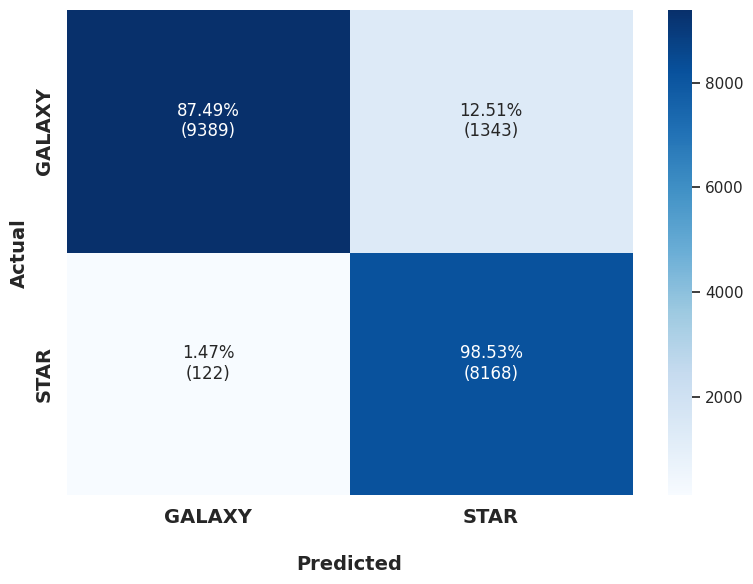

In [13]:
# Set the model to evaluation mode
model.load_state_dict(torch.load(os.path.join(out_dir2, 'EX1_SG_BayesianMargNet_Model.pth'), map_location=device))
model.eval()

y_test_pred = torch.empty(0).to(device)

# Generate predictions
with torch.no_grad():
    for images, pfs, labels in dataloader1:
        images = images.to(device)
        pfs = pfs.to(device)
        labels = labels.to(device)
        pred, _ = model([images, pfs])

        y_test_pred = torch.cat((y_test_pred, pred), dim=0)

y_test_pred = y_test_pred.cpu().numpy()
y_test_pred = y_test_pred.argmax(axis=1)
print(get_metrics(y_test_pred, y_test, label_strings))

# https://www.stackvidhya.com/plot-confusion-matrix-in-python-and-why/#google_vignette
# fig = plt.figure()
cf_matrix = metrics.confusion_matrix(y_test_pred, y_test)
cf_matrix_percentage = metrics.confusion_matrix(y_test_pred, y_test, normalize='true')
group_counts = ["{0:0.0f}".format(value) for value in cf_matrix.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in cf_matrix_percentage.flatten()]
labels = [f"{v1}\n({v2})\n" for v1, v2 in
          zip(group_percentages,group_counts)]
labels = np.asarray(labels).reshape(2,2)
fig, ax = plt.subplots(figsize=(8, 6))  # Adjust the size as needed

ax = sns.heatmap(cf_matrix, annot=labels, fmt='', cmap='Blues')
ax.set_xlabel('\nPredicted', fontsize=14, weight='bold')
ax.set_ylabel('Actual', fontsize=14, weight='bold');
ax.xaxis.set_ticklabels(['GALAXY', 'STAR'], fontsize=14, weight='bold')
ax.yaxis.set_ticklabels(['GALAXY', 'STAR'], fontsize=14, weight='bold')
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "EX3_SG_BayesianMargNet_CM.png"))
plt.show()
plt.close()

## Result Analysis

In [14]:
del(dnnx_test, X_test, y_test)

In [15]:
X = np.load("/scratch/srinadb/Foundation/Dataset/Experiment1/X_exp1.npy")
dnnx = np.load("/scratch/srinadb/Foundation/Dataset/Experiment1/dnnx_exp1.npy")
objlist = np.load("/scratch/srinadb/Foundation/Dataset/Experiment1/objlist_exp1.npy")
y = np.load("/scratch/srinadb/Foundation/Dataset/Experiment1/y_exp1.npy", allow_pickle=True)

idx_drop = np.where(y=="QSO")[0]
X = np.delete(X,idx_drop,axis=0)
dnnx = np.delete(dnnx,idx_drop,axis=0)
y = np.delete(y,idx_drop,axis=0)
objlist = np.delete(objlist,idx_drop,axis=0)
y, label_strings = pd.factorize(y,sort=True)
# y = to_categorical(y)
print('\n')
print(label_strings)

zipX = list(zip(X, dnnx))
zipy = list(zip(y, objlist))

zipX_train, zipX_test, zipy_train, zipy_test = train_test_split(zipX, zipy, test_size = 0.125,random_state=42)
zipX_train, zipX_val, zipy_train, zipy_val = train_test_split(zipX_train, zipy_train, test_size = 0.1428, random_state=42)

X_train, dnnx_train = zip(*zipX_train)
X_val, dnnx_val = zip(*zipX_val)
X_test, dnnx_test = zip(*zipX_test)

y_train, objlist_train = zip(*zipy_train)
y_val, objlist_val = zip(*zipy_val)
y_test, objlist_test = zip(*zipy_test)

X_train = np.array(X_train)
X_val = np.array(X_val)
X_test = np.array(X_test)

dnnx_train = np.array(dnnx_train)
dnnx_val = np.array(dnnx_val)
dnnx_test = np.array(dnnx_test)

y_train = np.array(y_train)
objlist_train = np.array(objlist_train)
y_val = np.array(y_val)
objlist_val = np.array(objlist_val)
y_test = np.array(y_test)
objlist_test = np.array(objlist_test)

del(zipX,zipX_test,zipX_train,zipX_val, X, zipy, zipy_test, zipy_train, zipy_val, objlist, X_test, y_test, dnnx_test)

dnnx_test = np.load("/scratch/srinadb/Foundation/Dataset/Experiment3/dnnx_sg_exp3.npy")
X_test = np.load("/scratch/srinadb/Foundation/Dataset/Experiment3/X_sg_exp3.npy")
y_test = np.load("/scratch/srinadb/Foundation/Dataset/Experiment3/y_sg_exp3.npy")
y_test = np.argmax(y_test, axis=1)

X_train = X_train.transpose((0, 3, 1, 2))
X_val = X_val.transpose((0, 3, 1, 2))
X_test = X_test.transpose((0, 3, 1, 2))

print('\n')
print('The shape of the Train data is:', X_train.shape)
print('The shape of the Validation data is:', X_val.shape)
print('The shape of the Test data is:', X_test.shape)

# Convert data to PyTorch tensors and create DataLoader
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
dnnx_train_tensor = torch.tensor(dnnx_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
dnnx_val_tensor = torch.tensor(dnnx_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
dnnx_test_tensor = torch.tensor(dnnx_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)


train_dataset = TensorDataset(X_train_tensor, dnnx_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=False)

val_dataset = TensorDataset(X_val_tensor, dnnx_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)

test_dataset = TensorDataset(X_test_tensor, dnnx_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)





['GALAXY' 'STAR']


The shape of the Train data is: (120007, 5, 32, 32)
The shape of the Validation data is: (19992, 5, 32, 32)
The shape of the Test data is: (19022, 5, 32, 32)


In [16]:
def get_preds(loader):
    model.eval()
    all_logits = []

    with torch.no_grad():
        for images, pf, labels in loader:
            pf = pf.to(device)
            images = images.to(device)

            out = model([images, pf])  # could be Tensor OR tuple/list
            logits = out[0] if isinstance(out, (tuple, list)) else out

            all_logits.append(logits.detach().cpu())

    all_logits = torch.cat(all_logits, dim=0)
    all_probs  = F.softmax(all_logits, dim=1).numpy()
    pred_labels = all_probs.argmax(axis=1)
    return all_probs, pred_labels

preds_train, y_train_pred = get_preds(train_loader)
print(get_metrics(y_train_pred, y_train, label_strings))
print('\n')

preds_val, y_val_pred = get_preds(val_loader)
print(get_metrics(y_val_pred, y_val, label_strings))
print('\n')

preds_test, y_test_pred = get_preds(test_loader)
print(get_metrics(y_test_pred, y_test, label_strings))


Identified 118363 correct labels out of 120007 labels
Accuracy: 0.9863007991200513
Precision: 0.9863063738692458
Recall: 0.9863037737789453
F1 Score: 0.9863007934802512
Labels are: ['GALAXY' 'STAR']
Confusion Matrix:
 [[59143   947]
 [  697 59220]]
Classification_Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.99     60090
           1       0.98      0.99      0.99     59917

    accuracy                           0.99    120007
   macro avg       0.99      0.99      0.99    120007
weighted avg       0.99      0.99      0.99    120007

(array([     0,      1,      2, ..., 120004, 120005, 120006]), 0.9863007991200513, 0.9863063738692458, 0.9863037737789453, array([[59143,   947],
       [  697, 59220]]), '              precision    recall  f1-score   support\n\n           0       0.99      0.98      0.99     60090\n           1       0.98      0.99      0.99     59917\n\n    accuracy                           0.99    120007\n   m

In [17]:
df  = pd.read_csv("/scratch/srinadb/Foundation/Dataset/Experiment1/photofeatures_exp1.csv", index_col=0)
df1 = pd.read_csv("/scratch/srinadb/Foundation/Dataset/Experiment3/photofeatures_exp3.csv", index_col=0)

df = df[df["class"]!="QSO"].reset_index()
df = df.set_index(["objid"])

df1 = df1[df1["class"]!="QSO"].reset_index()
df1 = df1.set_index(["objid"])

objlist_test = df1.index.tolist()

df.loc[objlist_train, ["set"]] = "TRAIN"
df.loc[objlist_val, ["set"]] = "VALIDATION"
df1.loc[objlist_test, ["set"]] = "TEST"

df.loc[objlist_train, ["pred_class"]] = label_strings[preds_train.argmax(axis=1)]
df.loc[objlist_val, ["pred_class"]] = label_strings[preds_val.argmax(axis=1)]
df1.loc[objlist_test, ["pred_class"]] = label_strings[preds_test.argmax(axis=1)]

pgal_train = preds_train[:,np.where(label_strings=="GALAXY")[0][0]]
pstar_train = preds_train[:,np.where(label_strings=="STAR")[0][0]]

pgal_val = preds_val[:,np.where(label_strings=="GALAXY")[0][0]]
pstar_val = preds_val[:,np.where(label_strings=="STAR")[0][0]]

pgal_test = preds_test[:,np.where(label_strings=="GALAXY")[0][0]]
pstar_test = preds_test[:,np.where(label_strings=="STAR")[0][0]]

df_tv   = df.loc[list(objlist_train) + list(objlist_val)].copy()
df_test = df1.loc[objlist_test].copy()

df_all = pd.concat([df_tv, df_test], axis=0)
df_all.to_csv(os.path.join(out_dir, "EX3_SG_BayesianMargNet_results.csv"))

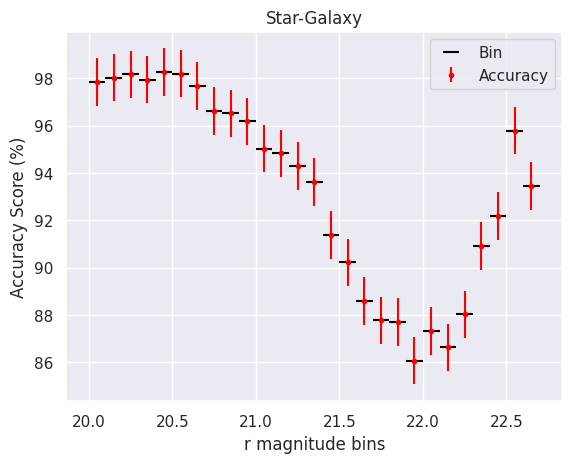

In [18]:
sns.set_palette("tab10")

df = pd.read_csv(os.path.join(out_dir, "EX3_SG_BayesianMargNet_results.csv"))

subdflist = []

bin_size = 0.1
lower_bin_list = np.arange(20,23,bin_size)
bad_lower_bin=[]
acclist = []
f1list = []
reportlist = []
num_samplelist = []
starmaglist = []
galmaglist = []

for lower_bin in lower_bin_list:
#     print(f"******************** {lower_bin} < r <= {lower_bin+bin_size} ********************")
    subdf = df[(
        ((df["dered_r"]+df["extinction_r"]) > lower_bin) & 
        ((df["dered_r"]+df["extinction_r"]) <= lower_bin+bin_size)
    )]
    # Choose equal number of stars and galaxies
    min_num = subdf["class"].value_counts().min()
    if min_num < 50:
        bad_lower_bin.append(lower_bin)
        continue
    s1 = subdf[subdf["class"]=="GALAXY"].sample(n=min_num)
    galmaglist.append((s1["dered_r"]+s1["extinction_r"]).to_numpy())
    s2 = subdf[subdf["class"]=="STAR"].sample(n=min_num)
    starmaglist.append((s2["dered_r"]+s2["extinction_r"]).to_numpy())
    num_samplelist.append(min_num)
    subdf = pd.concat([s1,s2])
    subdflist.append(subdf)
    
    accuracy = metrics.accuracy_score(subdf["class"], subdf["pred_class"])
    f1score = metrics.f1_score(subdf["class"], subdf["pred_class"],average='macro')
    report = metrics.classification_report(subdf["class"], subdf["pred_class"],output_dict=True)
    reportlist.append(report)
    acclist.append(accuracy)
    f1list.append(f1score)

bad_lower_bin = np.array(bad_lower_bin)
lower_bin_list = lower_bin_list[~np.in1d(lower_bin_list,bad_lower_bin)]
# elems in lower_bin_list not in bad_lower_bin

galmaglist = np.concatenate(galmaglist)

starmaglist = np.concatenate(starmaglist)

plt.errorbar(lower_bin_list+bin_size/2, np.array(acclist)*100, xerr=bin_size/2, fmt=" ",color="black",label="Bin")
plt.errorbar(lower_bin_list+bin_size/2, np.array(acclist)*100, yerr=0.01*100,fmt=".",color="red",label="Accuracy")
# plt.errorbar(lower_bin_list+bin_size/2, f1list, yerr=0.01,label="F1 Score")
plt.legend()
plt.title("Star-Galaxy")
plt.xlabel("r magnitude bins")
plt.ylabel("Accuracy Score (%)")
# plt.ylim(93, 100)
# os.path.join(out_dir, "EX1_SG_MargNet_results.csv")
plt.savefig(os.path.join(out_dir, "EX3_SG_BayesianMargNet_v2.png")) 


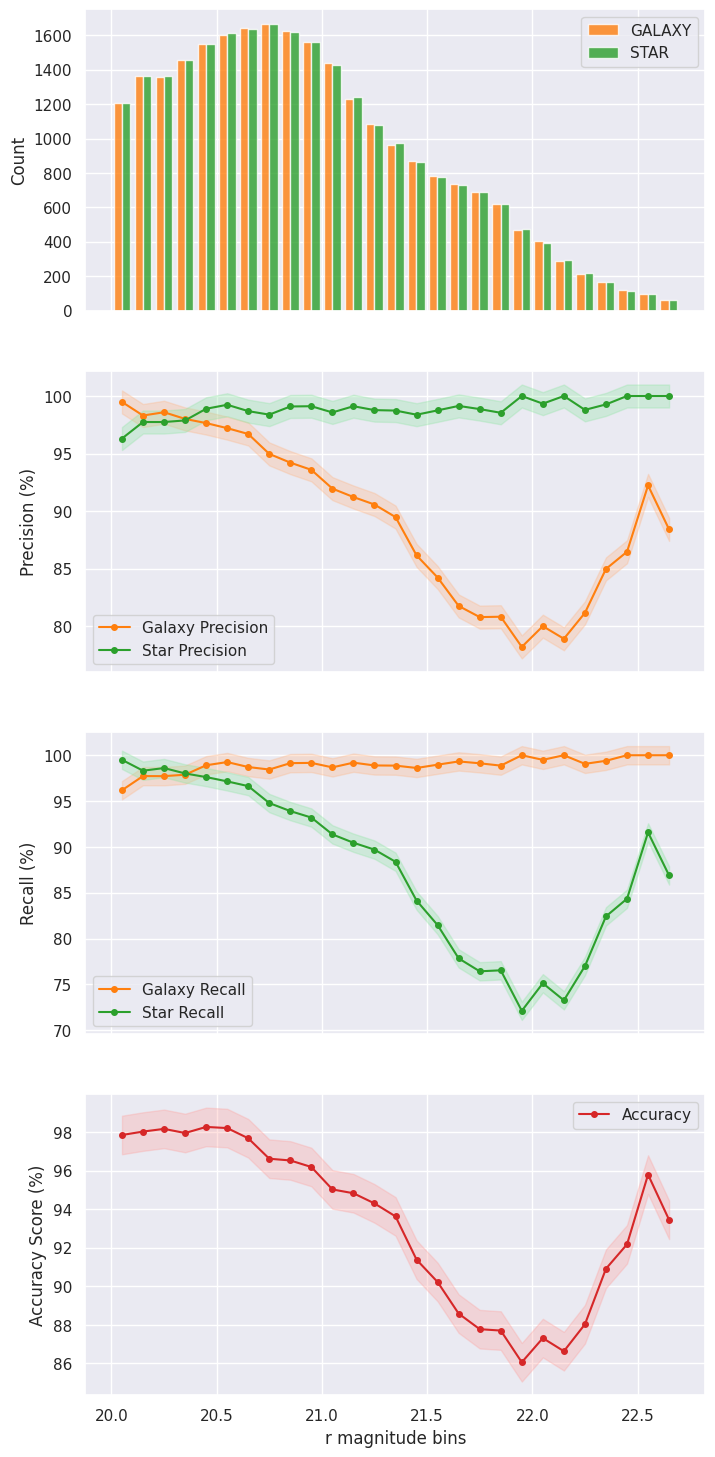

In [19]:
subdfs = pd.concat(subdflist)
subdfs["r"]=subdfs["dered_r"]+subdfs["extinction_r"]

gal_recall_list = []
gal_precision_list = []
star_recall_list = []
star_precision_list = []
for r in reportlist:
    gal_recall_list.append(r["GALAXY"]["recall"])
    gal_precision_list.append(r["GALAXY"]["precision"])
    star_recall_list.append(r["STAR"]["recall"])
    star_precision_list.append(r["STAR"]["precision"])
    
    
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1,sharex=True, figsize=(8,18))

galcolor = sns.color_palette("tab10")[1]
starcolor = sns.color_palette("tab10")[2]
acccolor = sns.color_palette("tab10")[3]
f1color = sns.color_palette("tab10")[4]

dyfit = 0.01
x_ax = lower_bin_list+bin_size/2


d1 = subdfs[subdfs["class"]=="GALAXY"]["r"]
d2 = subdfs[subdfs["class"]=="STAR"]["r"]

ax1.hist([d1, d2], color=[galcolor,starcolor],
         alpha=0.8, label=["GALAXY","STAR"],bins=len(lower_bin_list))
ax1.set_ylabel("Count")

ax1.legend()


y_ax1 = np.array(gal_precision_list)
y_ax2 = np.array(star_precision_list)

ax2.errorbar(x_ax, y_ax1*100,fmt="-o", ms=4, label="Galaxy Precision",color=galcolor)
ax2.fill_between(x_ax, y_ax1*100 - dyfit*100, y_ax1*100 + dyfit*100,
             color=sns.color_palette("pastel")[1], alpha=0.3)
ax2.errorbar(x_ax, y_ax2*100,fmt="-o", ms=4, label="Star Precision",color=starcolor)
ax2.fill_between(x_ax, y_ax2*100 - dyfit*100, y_ax2*100 + dyfit*100,
                 color=sns.color_palette("pastel")[2], alpha=0.3)
ax2.set_ylabel("Precision (%)")
ax2.legend()



y_ax1 = np.array(gal_recall_list)
y_ax2 = np.array(star_recall_list)

ax3.errorbar(x_ax, y_ax1*100,fmt="-o", ms=4, label="Galaxy Recall",color=galcolor)
ax3.fill_between(x_ax, y_ax1*100 - dyfit*100, y_ax1*100 + dyfit*100,
             color=sns.color_palette("pastel")[1], alpha=0.3)
ax3.errorbar(x_ax, y_ax2*100,fmt="-o", ms=4, label="Star Recall",color=starcolor)
ax3.fill_between(x_ax, y_ax2*100 - dyfit*100, y_ax2*100 + dyfit*100,
             color=sns.color_palette("pastel")[2], alpha=0.3)
ax3.set_ylabel("Recall (%)")
ax3.legend()



y_ax1 = np.array(acclist)
y_ax2 = np.array(f1list)
ax4.errorbar(x_ax, y_ax1*100,fmt="-o", ms=4, label="Accuracy",color=acccolor)
# ax4.errorbar(x_ax, y_ax2*100,fmt="-o", ms=4, label="F1 Score",color=f1color)
ax4.fill_between(x_ax, y_ax1*100 - dyfit*100, y_ax1*100 + dyfit*100,
             color=sns.color_palette("pastel")[3], alpha=0.3)
ax4.set_ylabel("Accuracy Score (%)")
ax4.legend()

plt.xlabel("r magnitude bins")


# plt.suptitle("Star-Galaxy")
plt.savefig(os.path.join(out_dir, "EX3_SG_BayesianMargNet_v2Set.png")) 
plt.show()    
